In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('C:\\Users\\Admin\\OneDrive\\Desktop\\data science\\ML\\SUPERVISED LEARNING\\Dataset\\Ice_cream selling data.csv')

In [3]:
X = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

In [4]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


This is weakly relation between this two columns 

In [5]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=42)

In [6]:
model = LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
train_score = model.score(xtrain,ytrain)
test_score = model.score(xtest,ytest)

In [8]:
print(f'train score : {train_score}\ntest score : {test_score}')

train score : 0.06579063815950037
test score : -0.5751270190188227


**model is under fit**

why model is under fit?

model (linear model) is too simple not able to capture the complex patterns non linear data

**solution**

PolynomialFeatures + LinearRegression

## methods
fit_tranform()  --->  it creates the features based on degree.
learns the pattern, creating extra features,transform the values

transform() --->  transform the values


In [9]:
poly = PolynomialFeatures(degree=3)
'''
fit_transform()

fit - learns the pattern
transform the learned pattern (fit)

PolynomialFeatures() 
how fit transform() works in PolynomialFeatures ?

fit - based on actual input(features) it adds new features based on degree (parameter)
transform - transform the values for created(added) columns

syntax
poly.fit_transform(xtrain)
'''

'\nfit_transform()\n\nfit - learns the pattern\ntransform the learned pattern (fit)\n\nPolynomialFeatures() \nhow fit transform() works in PolynomialFeatures ?\n\nfit - based on actual input(features) it adds new features based on degree (parameter)\ntransform - transform the values for created(added) columns\n\nsyntax\npoly.fit_transform(xtrain)\n'

In [10]:
xtrain_poly = poly.fit_transform(xtrain)

preprocessing only for features column not target column

In [11]:
xtrain_poly.shape

(39, 4)

In [12]:
model.fit(xtrain_poly,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## predict we use polinomial data

In [13]:
ytrain_preticted = model.predict(xtrain_poly)

In [14]:
train_scor = model.score(xtrain_poly,ytrain)
# test_score = model.score(xtest,ytest)
print(f'Train Score : {train_scor}')

Train Score : 0.9469116778215552


## Train Data prediction

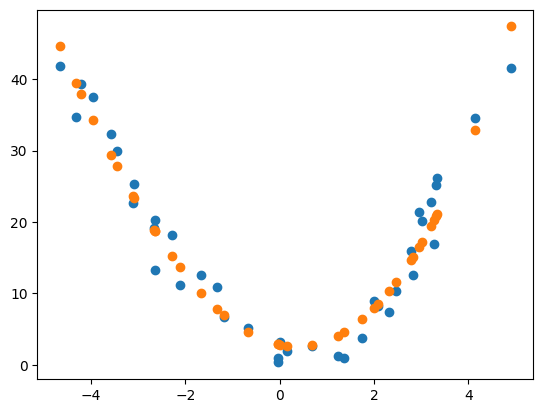

In [15]:
plt.scatter(xtrain,ytrain)

plt.scatter(xtrain,ytrain_preticted)

## Test Data Prediction 

Test Score : 0.8405107685716915


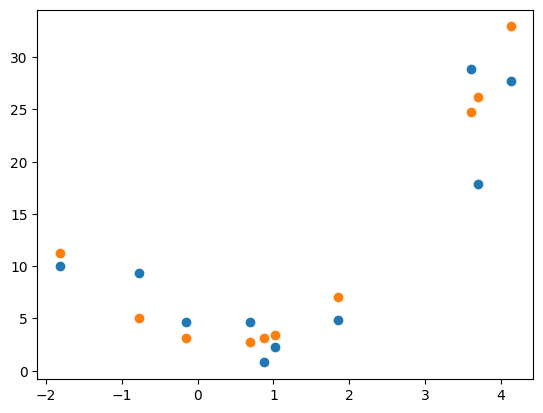

In [16]:
xtest_poly = poly.transform(xtest)

ytest_preticted = model.predict(xtest_poly)

test_score = model.score(xtest_poly,ytest)
print(f"Test Score : {test_score}")

plt.scatter(xtest,ytest)

plt.scatter(xtest,ytest_preticted)